# Lab 07 — Deep learning I: a first neural network and a CNN for images

*Train a dense network and a convolutional network on the handwritten digits*

**Goal.** Turn the digit images into tensors, write one training loop and read its curves, compare a dense network with a convolutional one against the classical baseline from Lab 4, look at what the CNN learned, and save the weights with a model card.

**Data.** `all_datasets/optical_recognition_handwritten_digits.zip` (read in place)

**Reading.** Chapter 21 (Neural Networks, CNNs, and Sequence Models)

**Run.** Open a terminal in the course folder, run `cd all_experiments` and `jupyter lab`, open this notebook, and choose **Restart Kernel and Run All Cells**.

**Evidence.** `results/lab07/` — training curves, test metrics, confusion matrix, misread digits, learned filters; `models/digits_cnn.pt` and its card

**How much is scaffolded?** Fully worked. The training loop is written out in full once so every step is visible; the CNN reuses it unchanged.

**Workflow**

1. Part A — Images as tensors
2. Part B — A first neural network and the training loop
3. Part C — A convolutional network
4. Part D — Save the weights with a card
5. Try it yourself, with one solution

## Setup

Imports and paths. Notebooks run from `all_experiments/`, so the course folder is one level up; figures and tables go to `results/lab07/`.

In [1]:
import re
import json
import os
import zipfile
from pathlib import Path

# Anaconda's NumPy and pip's PyTorch each ship an OpenMP runtime on Windows; let them coexist.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from torch import nn

torch.manual_seed(42)
PROJECT_ROOT = Path.cwd().parent
DATA = PROJECT_ROOT / "all_datasets"
MODELS = PROJECT_ROOT / "models"
MODELS.mkdir(exist_ok=True)
print("PyTorch", torch.__version__, "| device: cpu")

RESULTS = PROJECT_ROOT / "results" / "lab07"
RESULTS.mkdir(parents=True, exist_ok=True)
print("course folder:", PROJECT_ROOT.name)

PyTorch 2.14.0+cpu | device: cpu
course folder: MACHINE LEARNING


## Part A — Images as tensors

The same digits as Lab 4: each is an $8\times8$ grid of brightness values from 0 to 16. PyTorch works on *tensors*, which are arrays that remember how to compute gradients. A convolutional layer expects images as (batch, channels, height, width), so each row of 64 numbers is reshaped to $1\times8\times8$ and scaled to $[0,1]$. The official test file stays closed until the end; a validation quarter is carved from the training file.

fit: torch.Size([2868, 1, 8, 8])  validation: torch.Size([955, 1, 8, 8])  test: torch.Size([1797, 1, 8, 8])


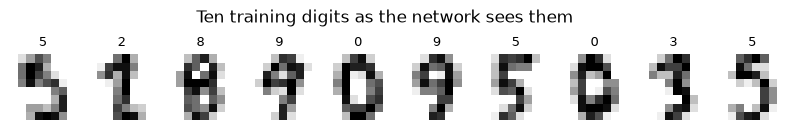

In [2]:
columns = [f"pixel_{i}" for i in range(64)] + ["label"]
with zipfile.ZipFile(DATA / "optical_recognition_handwritten_digits.zip") as archive:
    members = {Path(name).name: name for name in archive.namelist()}
    train = pd.read_csv(archive.open(members["optdigits.tra"]), header=None, names=columns)
    test = pd.read_csv(archive.open(members["optdigits.tes"]), header=None, names=columns)

def to_tensors(frame):
    X = torch.tensor(frame.drop(columns="label").to_numpy(), dtype=torch.float32)
    X = X.reshape(-1, 1, 8, 8) / 16.0            # (rows, channels, height, width), values in [0, 1]
    y = torch.tensor(frame["label"].to_numpy(), dtype=torch.long)
    return X, y

X_dev, y_dev = to_tensors(train)
X_test, y_test = to_tensors(test)
perm = torch.randperm(len(X_dev), generator=torch.Generator().manual_seed(42))
n_val = len(X_dev) // 4
X_val, y_val = X_dev[perm[:n_val]], y_dev[perm[:n_val]]
X_fit, y_fit = X_dev[perm[n_val:]], y_dev[perm[n_val:]]
print("fit:", X_fit.shape, " validation:", X_val.shape, " test:", X_test.shape)

fig, axes = plt.subplots(1, 10, figsize=(10, 1.4))
for ax, image, label in zip(axes, X_fit[:10], y_fit[:10]):
    ax.imshow(image[0], cmap="gray_r")
    ax.set_title(int(label), fontsize=9)
    ax.axis("off")
plt.suptitle("Ten training digits as the network sees them", y=1.05)
plt.savefig(RESULTS / "ten_training_digits_as_the_network_sees_them.png", dpi=160, bbox_inches="tight")
plt.show()

**What the output shows.** 3,823 training digits become 2,868 for fitting and 955 for validation; the 1,797 official test digits stay sealed. Each image is one channel of 8×8 values in [0, 1].

## Part B — A first neural network and the training loop

A dense network flattens the 64 pixels into a vector, computes 128 weighted sums, passes each through ReLU, and computes 10 class scores from those. Written in `nn.Sequential`, it is four lines. The classical baseline is logistic regression on the same pixels: one weighted sum per class and no hidden layer.

In [3]:
def make_mlp():
    return nn.Sequential(
        nn.Flatten(),                 # 1 x 8 x 8  ->  64
        nn.Linear(64, 128), nn.ReLU(),
        nn.Linear(128, 10),           # ten class scores
    )

mlp = make_mlp()
print(mlp)
print("trainable weights:", sum(p.numel() for p in mlp.parameters()))

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=64, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=10, bias=True)
)
trainable weights: 9610


The training loop is the whole method. Each epoch shuffles the training rows and walks through them in batches of 32. For each batch: compute the class scores (forward pass), compute the cross-entropy loss, compute every gradient with `backward()`, and let the optimizer move every weight a small step. After each epoch, accuracy is recorded on the training and validation sets so the curves can be read as in the notes.

In [4]:
def accuracy(model, X, y):
    model.eval()
    with torch.no_grad():
        return (model(X).argmax(dim=1) == y).float().mean().item()

def train_classifier(model, X, y, X_v, y_v, epochs=20, lr=3e-3, batch_size=32):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    history = {"train": [], "validation": []}
    for epoch in range(epochs):
        model.train()
        order = torch.randperm(len(X))
        for start in range(0, len(X), batch_size):
            batch = order[start:start + batch_size]
            optimizer.zero_grad()                    # forget the previous gradients
            loss = loss_fn(model(X[batch]), y[batch])
            loss.backward()                          # backpropagation: gradient for every weight
            optimizer.step()                         # move every weight a small step
        history["train"].append(accuracy(model, X, y))
        history["validation"].append(accuracy(model, X_v, y_v))
    return history

torch.manual_seed(42)
mlp_history = train_classifier(mlp, X_fit, y_fit, X_val, y_val)
print("dense network: validation accuracy =", round(mlp_history["validation"][-1], 4))

dense network: validation accuracy = 0.9759


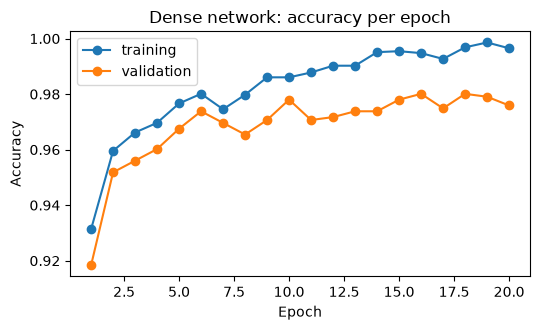

In [5]:
def plot_history(history, title):
    plt.figure(figsize=(5.5, 3.4))
    plt.plot(range(1, len(history["train"]) + 1), history["train"], marker="o", label="training")
    plt.plot(range(1, len(history["validation"]) + 1), history["validation"],
             marker="o", label="validation")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(RESULTS / (re.sub(r"[^a-z0-9]+", "_", title.lower()).strip("_") + ".png"), dpi=160, bbox_inches="tight")
    plt.show()

plot_history(mlp_history, "Dense network: accuracy per epoch")

**What to look for.** Training accuracy heads towards 1.0 while validation accuracy flattens after a handful of epochs: the same overfitting picture as the tree-depth curve in Lab 3, drawn against epochs instead of depth. If the validation curve started falling, you would stop early and keep the best epoch.

**What the output shows.** The dense network has 9,610 weights and reaches about 0.976 validation accuracy after 20 epochs. Training accuracy keeps climbing while validation flattens after a few epochs: the tree-depth picture from Lab 3, drawn against epochs.

## Part C — A convolutional network

A CNN keeps the image as a grid. The first layer slides sixteen $3\times3$ filters across it and produces sixteen feature maps; max pooling halves each map; a second layer does the same with thirty-two filters; the result is flattened and classified by a small dense layer. Printing the shape after each stage shows where the numbers go.

In [6]:
def make_cnn():
    return nn.Sequential(
        nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 16 x 4 x 4
        nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 32 x 2 x 2
        nn.Flatten(),                                                             # 128
        nn.Linear(32 * 2 * 2, 64), nn.ReLU(), nn.Dropout(0.2),
        nn.Linear(64, 10),
    )

cnn = make_cnn()
print("trainable weights:", sum(p.numel() for p in cnn.parameters()))
sample = X_fit[:1]
for layer in cnn:
    sample = layer(sample)
    if isinstance(layer, (nn.Conv2d, nn.MaxPool2d, nn.Flatten, nn.Linear)):
        print(f"{layer.__class__.__name__:10s} -> {tuple(sample.shape[1:])}")

trainable weights: 13706
Conv2d     -> (16, 8, 8)
MaxPool2d  -> (16, 4, 4)
Conv2d     -> (32, 4, 4)
MaxPool2d  -> (32, 2, 2)
Flatten    -> (128,)
Linear     -> (64,)
Linear     -> (10,)


The same loop trains it; nothing else changes.

CNN: validation accuracy = 0.9843


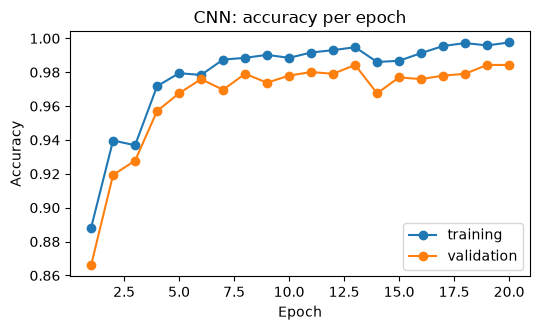

In [7]:
torch.manual_seed(42)
cnn_history = train_classifier(cnn, X_fit, y_fit, X_val, y_val)
print("CNN: validation accuracy =", round(cnn_history["validation"][-1], 4))
plot_history(cnn_history, "CNN: accuracy per epoch")

Now the official test file, opened once for each model. The third number is the PCA-plus-logistic result from Lab 4 on the same file.

logistic on PCA (Lab 4)    test accuracy = 0.9477
dense network              test accuracy = 0.9583
CNN                        test accuracy = 0.9711


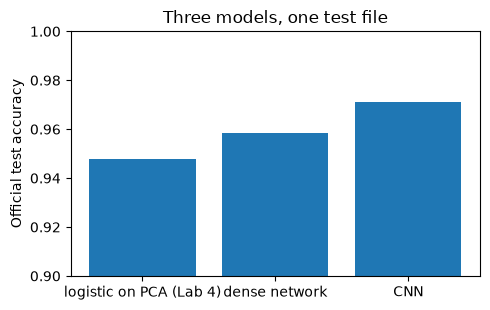

In [8]:
test_scores = {
    "logistic on PCA (Lab 4)": 0.9477,
    "dense network": accuracy(mlp, X_test, y_test),
    "CNN": accuracy(cnn, X_test, y_test),
}
for name, value in test_scores.items():
    print(f"{name:26s} test accuracy = {value:.4f}")

plt.figure(figsize=(5, 3.2))
plt.bar(list(test_scores), list(test_scores.values()))
plt.ylim(0.9, 1.0)
plt.ylabel("Official test accuracy")
plt.title("Three models, one test file")
plt.tight_layout()
plt.savefig(RESULTS / "three_models_one_test_file.png", dpi=160, bbox_inches="tight")
plt.show()

**What to look for.** Each step up the ladder buys about a point: the dense network beats the linear model, and the CNN beats the dense network, on 1,797 test digits. The CNN has more weights than the dense network but uses them better, because a filter that finds a stroke in one corner finds it in every corner.

Which digits does the CNN still confuse? A confusion matrix on the test file, and the misclassified images themselves, answer that.

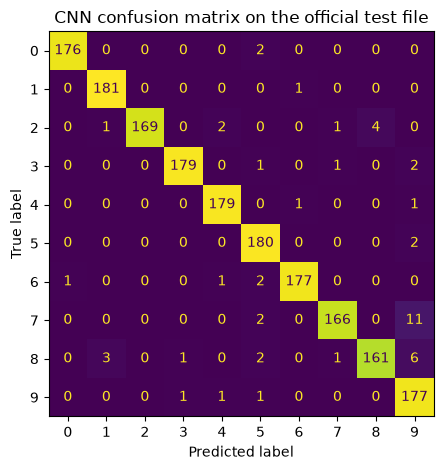

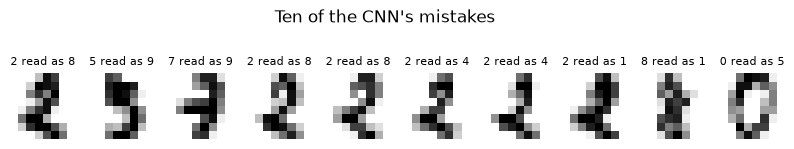

In [9]:
cnn.eval()
with torch.no_grad():
    test_pred = cnn(X_test).argmax(dim=1)

ConfusionMatrixDisplay.from_predictions(y_test.numpy(), test_pred.numpy(), colorbar=False)
plt.title("CNN confusion matrix on the official test file")
plt.tight_layout()
plt.savefig(RESULTS / "cnn_confusion_matrix_on_the_official_test_file.png", dpi=160, bbox_inches="tight")
plt.show()

wrong = torch.nonzero(test_pred != y_test).flatten()[:10]
fig, axes = plt.subplots(1, len(wrong), figsize=(10, 1.6))
for ax, i in zip(axes, wrong):
    ax.imshow(X_test[i, 0], cmap="gray_r")
    ax.set_title(f"{int(y_test[i])} read as {int(test_pred[i])}", fontsize=8)
    ax.axis("off")
plt.suptitle("Ten of the CNN's mistakes", y=1.1)
plt.savefig(RESULTS / "ten_of_the_cnn_s_mistakes.png", dpi=160, bbox_inches="tight")
plt.show()

**What to look for.** The errors sit off the diagonal in a few familiar places (8 and 1, 9 and 5, 3 and 8) and most of the misread digits are genuinely ambiguous at $8\times8$ pixels. A wrong prediction on a badly written digit is a different kind of failure from a systematic bias, and only looking at the images tells them apart.

What did the first layer learn? Its sixteen filters are $3\times3$ grids of weights, and they can be drawn directly.

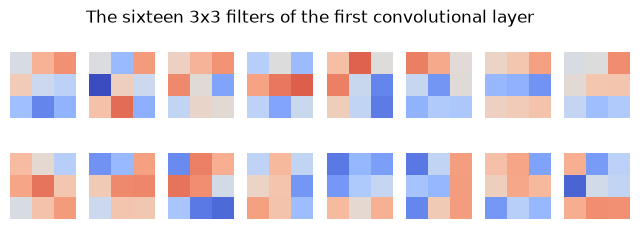

In [10]:
filters = cnn[0].weight.detach()[:, 0]
fig, axes = plt.subplots(2, 8, figsize=(8, 2.4))
for ax, kernel in zip(axes.flat, filters):
    ax.imshow(kernel, cmap="coolwarm", vmin=-filters.abs().max(), vmax=filters.abs().max())
    ax.axis("off")
plt.suptitle("The sixteen 3x3 filters of the first convolutional layer", y=1.02)
plt.savefig(RESULTS / "the_sixteen_3x3_filters_of_the_first_convolutional_layer.png", dpi=160, bbox_inches="tight")
plt.show()

**What to look for.** Several filters have a bright side and a dark side: they respond to an edge in one orientation. Nobody told the network to look for edges; they are what reduces the loss.

**What the output shows.** The CNN has 13,706 weights. On the official test file: logistic on PCA 0.948, dense network 0.958, CNN 0.971. Each step up buys about a point on 1,797 digits. The confusion matrix shows the familiar confusions, the misread images are mostly ambiguous at 8×8, and several first-layer filters have turned into edge detectors without being told to.

## Part D — Save the weights with a card

`torch.save` writes the learned weights (the *state dict*) to a file. Loading them requires building the same architecture first, which is why `make_cnn` and the model card belong beside the file. The reloaded model is checked against the in-memory one before the file is trusted.

In [11]:
weights_path = MODELS / "digits_cnn.pt"
torch.save(cnn.state_dict(), weights_path)

card = {
    "task": "classify 8x8 handwritten digits (0-9)",
    "input": "tensor of shape (n, 1, 8, 8), pixel values divided by 16",
    "architecture": "make_cnn() in Lab 7: conv16-pool-conv32-pool-dense64-dense10",
    "training": {"epochs": 20, "learning_rate": 3e-3, "batch_size": 32, "seed": 42},
    "official_test_accuracy": round(test_scores["CNN"], 4),
    "torch_version": torch.__version__,
}
(MODELS / "digits_cnn_card.json").write_text(json.dumps(card, indent=2))

restored = make_cnn()
restored.load_state_dict(torch.load(weights_path))
restored.eval()
with torch.no_grad():
    same = torch.equal(restored(X_test).argmax(dim=1), test_pred)
size_kb = weights_path.stat().st_size / 1024
print(f"saved {weights_path.name} ({size_kb:.0f} KB); reload reproduces predictions: {same}")

saved digits_cnn.pt (57 KB); reload reproduces predictions: True


**What the output shows.** `digits_cnn.pt` holds 57 KB of weights; the card records the architecture name, the input format, the training settings, and the test score. The restored network reproduces every test prediction.

## Evidence

Write the numbers above to the results folder. These files are regenerated on every run; do not edit them by hand.

In [12]:
pd.DataFrame({"epoch": range(1, len(mlp_history["train"]) + 1),
              "mlp_train": mlp_history["train"], "mlp_validation": mlp_history["validation"],
              "cnn_train": cnn_history["train"], "cnn_validation": cnn_history["validation"]}).round(4).to_csv(
    RESULTS / "training_curves.csv", index=False)
pd.Series(test_scores, name="official_test_accuracy").rename_axis("model").round(4).to_csv(RESULTS / "metrics.csv")
print("Saved:", sorted(p.name for p in RESULTS.iterdir()))

Saved: ['cnn_5_vs_40_epochs.png', 'cnn_accuracy_per_epoch.png', 'cnn_confusion_matrix_on_the_official_test_file.png', 'dense_network_accuracy_per_epoch.png', 'metrics.csv', 'ten_of_the_cnn_s_mistakes.png', 'ten_training_digits_as_the_network_sees_them.png', 'the_sixteen_3x3_filters_of_the_first_convolutional_layer.png', 'three_models_one_test_file.png', 'training_curves.csv']


## Try it yourself

Train the CNN for 5 epochs and for 40 epochs and compare the two accuracy curves: where does the validation curve stop improving? Then build a CNN with only the first convolutional block (delete the second `Conv2d`, `ReLU`, and `MaxPool2d`; the flattened size becomes $16\times4\times4$) and see whether the second block was earning its keep.

Attempt it in the cell below before reading the solution.

In [13]:
# Your work here


### One solution

The CNN trained for 5 and for 40 epochs, then a one-block CNN.

 5 epochs: validation accuracy = 0.9665, test accuracy = 0.9494


40 epochs: validation accuracy = 0.9822, test accuracy = 0.9755


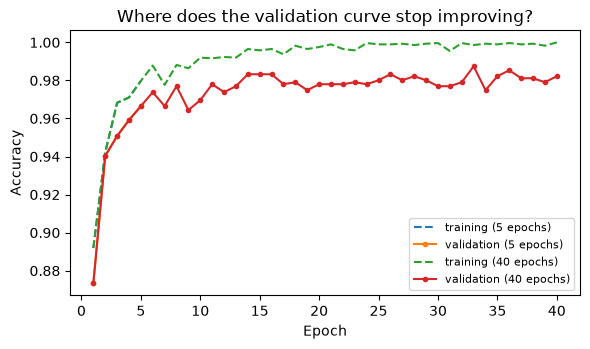

one-block CNN: weights = 17258  test accuracy = 0.9777
two-block CNN: weights = 13706  test accuracy = 0.9711


In [14]:
curves = {}
for epochs in [5, 40]:
    torch.manual_seed(42)
    net = make_cnn()
    curves[epochs] = train_classifier(net, X_fit, y_fit, X_val, y_val, epochs=epochs)
    print(f"{epochs:2d} epochs: validation accuracy = {curves[epochs]['validation'][-1]:.4f}, "
          f"test accuracy = {accuracy(net, X_test, y_test):.4f}")

plt.figure(figsize=(6, 3.6))
for epochs, h in curves.items():
    plt.plot(range(1, epochs + 1), h["train"], linestyle="--", label=f"training ({epochs} epochs)")
    plt.plot(range(1, epochs + 1), h["validation"], marker=".", label=f"validation ({epochs} epochs)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Where does the validation curve stop improving?")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(RESULTS / "cnn_5_vs_40_epochs.png", dpi=160, bbox_inches="tight")
plt.show()

def make_one_block_cnn():
    return nn.Sequential(
        nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 16 x 4 x 4
        nn.Flatten(),                                                             # 256
        nn.Linear(16 * 4 * 4, 64), nn.ReLU(), nn.Dropout(0.2),
        nn.Linear(64, 10),
    )

torch.manual_seed(42)
one_block = make_one_block_cnn()
train_classifier(one_block, X_fit, y_fit, X_val, y_val)
print("one-block CNN: weights =", sum(p.numel() for p in one_block.parameters()),
      " test accuracy =", round(accuracy(one_block, X_test, y_test), 4))
print("two-block CNN: weights =", sum(p.numel() for p in cnn.parameters()),
      " test accuracy =", round(test_scores["CNN"], 4))

**What it shows.** Five epochs are not enough: the validation curve is still rising when training stops (0.966 against 0.98 later). By forty, training accuracy is essentially 1.0 while validation has been wobbling within about half a point since epoch 10; the extra epochs changed the final score by less than that wobble, slightly for the better in this run, which is exactly why early stopping keeps the *best* epoch rather than the last. The one-block CNN is the surprise: it has more weights (the flattened vector is 256 rather than 128) and scores slightly *higher* on the test file, 0.978 against 0.971. At 8×8 pixels there is little for a second block to combine, because after one pooling the map is already 4×4; the second block earns its keep on larger images, and here it mostly adds depth the data does not need. An honest comparison beating the textbook expectation is a result worth keeping.